# Imports

In [1]:
from dairy_data_prep import df, df_w, pathogen_cols, weather_cols

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skfda.representation.grid import FDataGrid
from skfda.inference.hotelling import hotelling_test_ind
from skfda.representation.basis import BSplineBasis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.frameon": False,
    "figure.figsize": (9, 3)  # standard size for subplots
})
COLORS = ['#5F6F52', '#A9B388', '#B99470']

# Exploratory Data Analysis

Weather range: 2018-01-01 00:00:00 to 2019-04-23 00:00:00
Sample range:  2018-02-20 00:00:00 to 2019-03-05 00:00:00


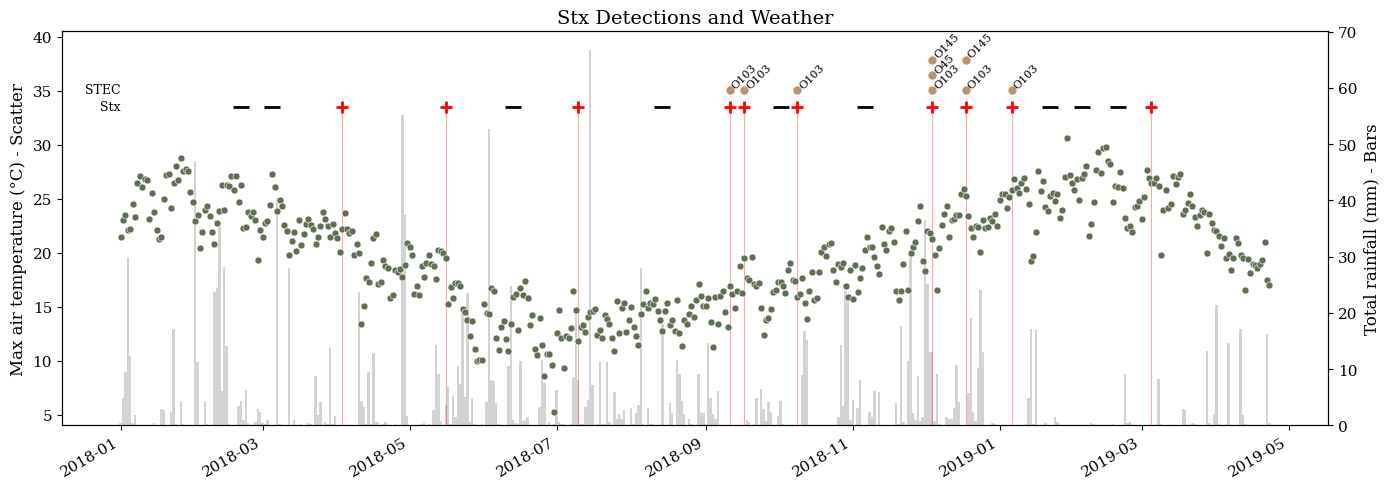

In [33]:
temp_col = "Max Air Temp (oC)"
rain_col = "Total Rainfall (mm)"
stx_col = "Stx (NeoSeek)"
o_cols = ["O103 (NeoSeek)", "O45 (NeoSeek)", "O145 (NeoSeek)"]

x_w = pd.to_datetime(df_w["Date"])
x_s = pd.to_datetime(df["Date"], dayfirst=True)

print("Weather range:", x_w.min(), "to", x_w.max())
print("Sample range: ", x_s.min(), "to", x_s.max())

fig, ax = plt.subplots(figsize=(14, 5))

sns.scatterplot(x=x_w, y=df_w[temp_col], ax=ax, s=25, color=COLORS[0], zorder=2)

ax_rain = ax.twinx()
ax.set_zorder(2)
ax_rain.set_zorder(1)
ax.patch.set_visible(False)
ax_rain.bar(x_w, df_w[rain_col], width=1, color="lightgray", zorder=1)

ymin, ymax = ax.get_ylim()
yrange = ymax - ymin

stx_y = ymax + 0.06 * yrange
otype_ys = {
    "O103 (NeoSeek)": ymax + 0.115 * yrange,
    "O45 (NeoSeek)": ymax + 0.165 * yrange,
    "O145 (NeoSeek)": ymax + 0.215 * yrange
}

ax.set_ylim(ymin, ymax + 0.31 * yrange)

stx_pos = df[stx_col].eq("+")
stx_neg = df[stx_col].eq("-")

ax.vlines(x_s[stx_pos], ymin=ymin, ymax=stx_y, color="red", linewidth=0.8, alpha=0.35, zorder=0)

ax.scatter(x_s[stx_neg], [stx_y] * stx_neg.sum(), marker="_", s=120, color="black", zorder=3)
ax.scatter(x_s[stx_pos], [stx_y] * stx_pos.sum(), marker="+", s=80, color="red", zorder=4)

for col in o_cols:
    detected = df[col] > 0
    label = col.replace(" (NeoSeek)", "")
    y = otype_ys[col]

    ax.scatter(x_s[detected], [y] * detected.sum(), s=25, color=COLORS[2], zorder=4)
    for d in x_s[detected]:
        ax.text(d, y, label, fontsize=8, rotation=45, ha="left", va="bottom")

ax.text(x_w.min(), stx_y, "Stx", ha="right", va="center", fontsize=9)
ax.text(x_w.min(), ymax + 0.115 * yrange, "STEC", ha="right", va="center", fontsize=9)

ax.set_ylabel("Max air temperature (°C) - Scatter")
ax_rain.set_ylabel("Total rainfall (mm) - Bars")
ax.set_xlabel("")
ax.set_title("Stx Detections and Weather")

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("figs/dairy_stx_weather_timeline.svg", bbox_inches="tight")
plt.savefig("figs/dairy_stx_weather_timeline.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot: Pathogen Occurrence vs. Weather before sampling

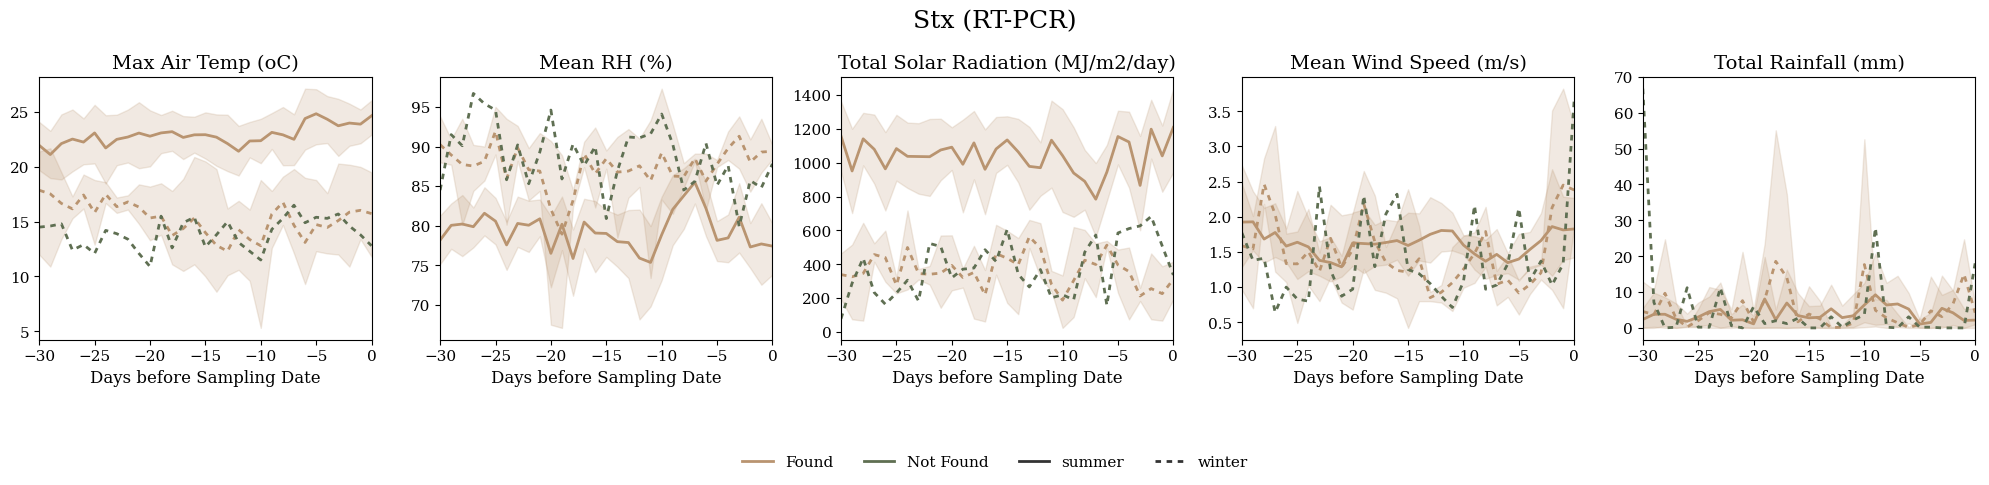

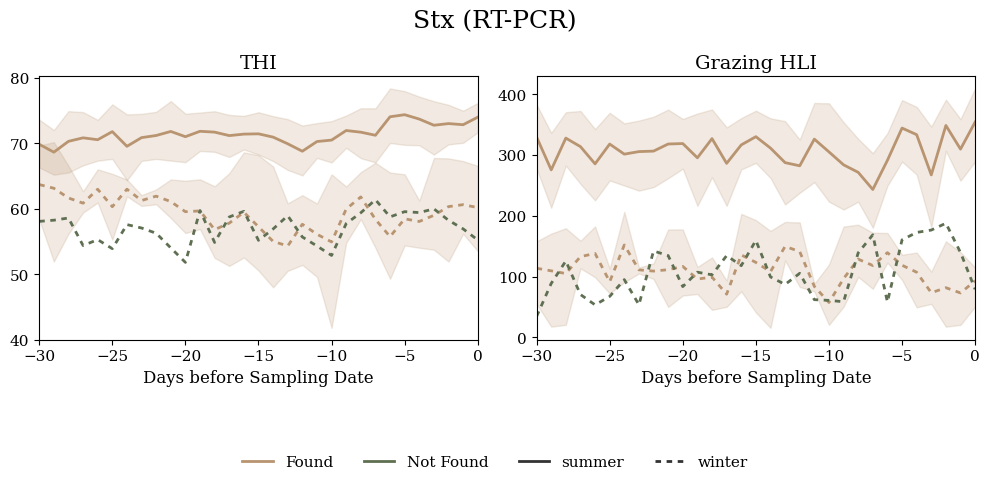

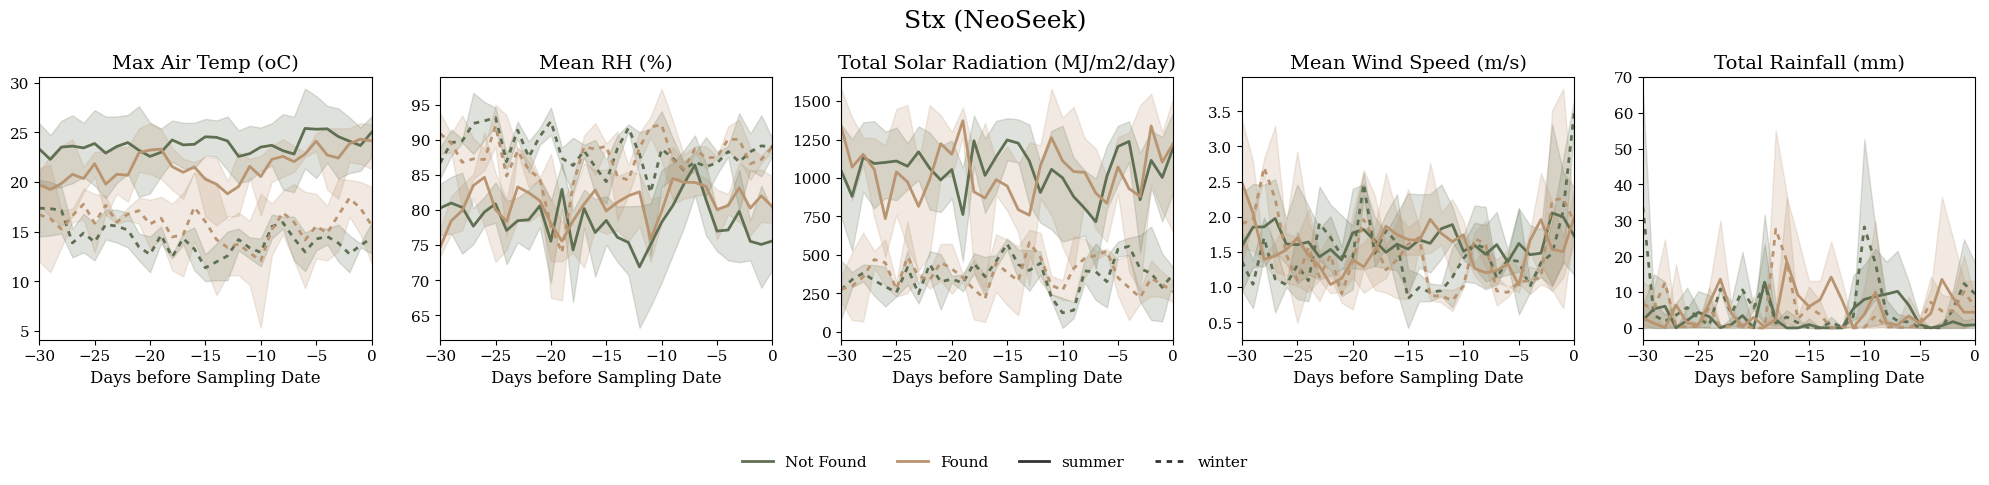

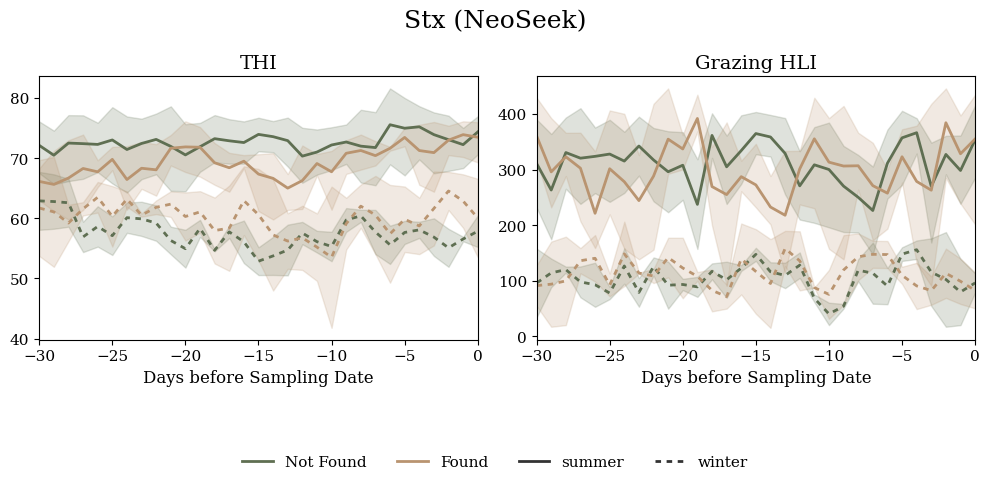

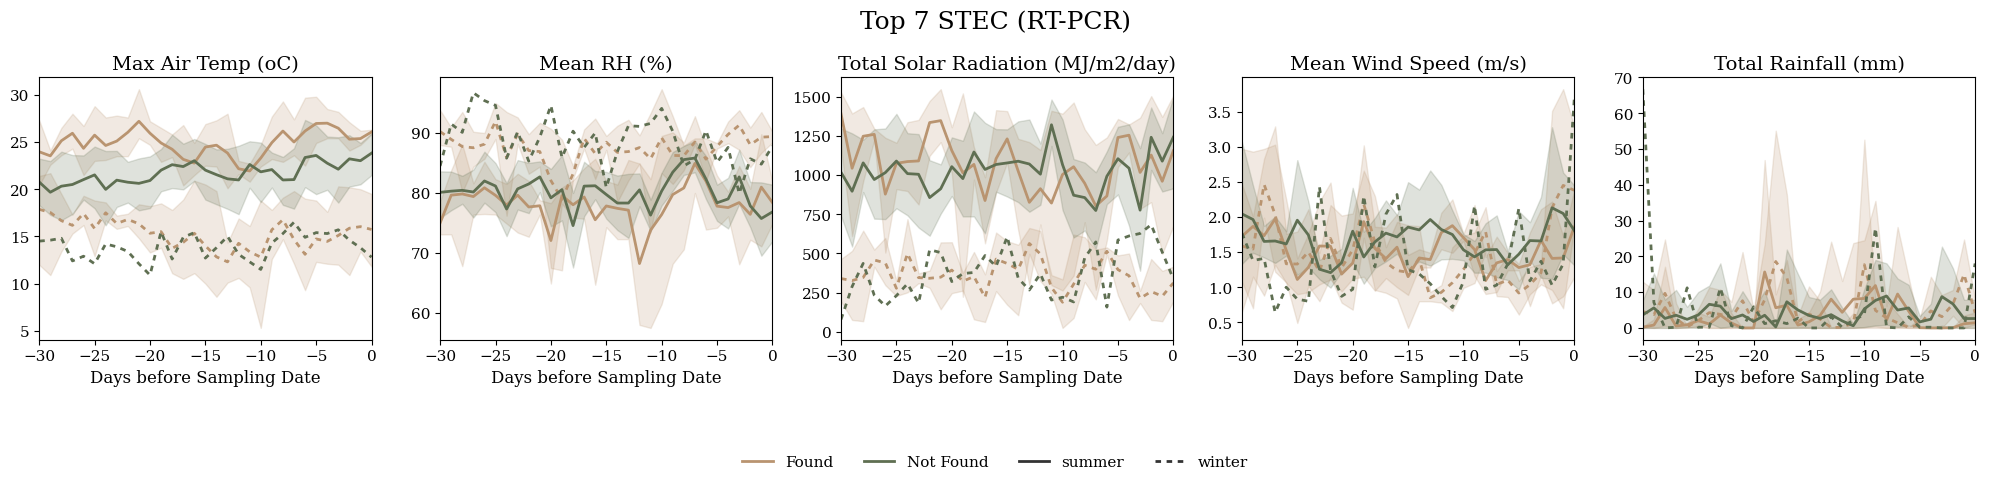

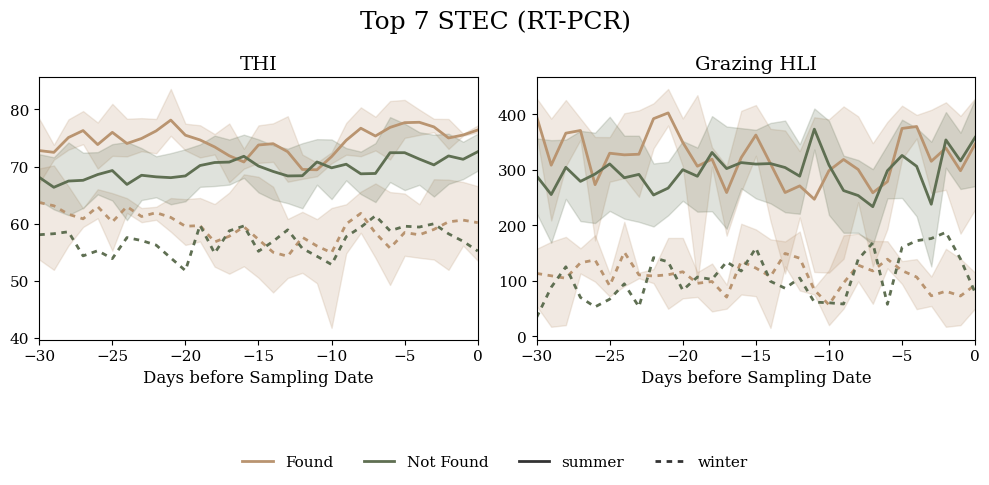

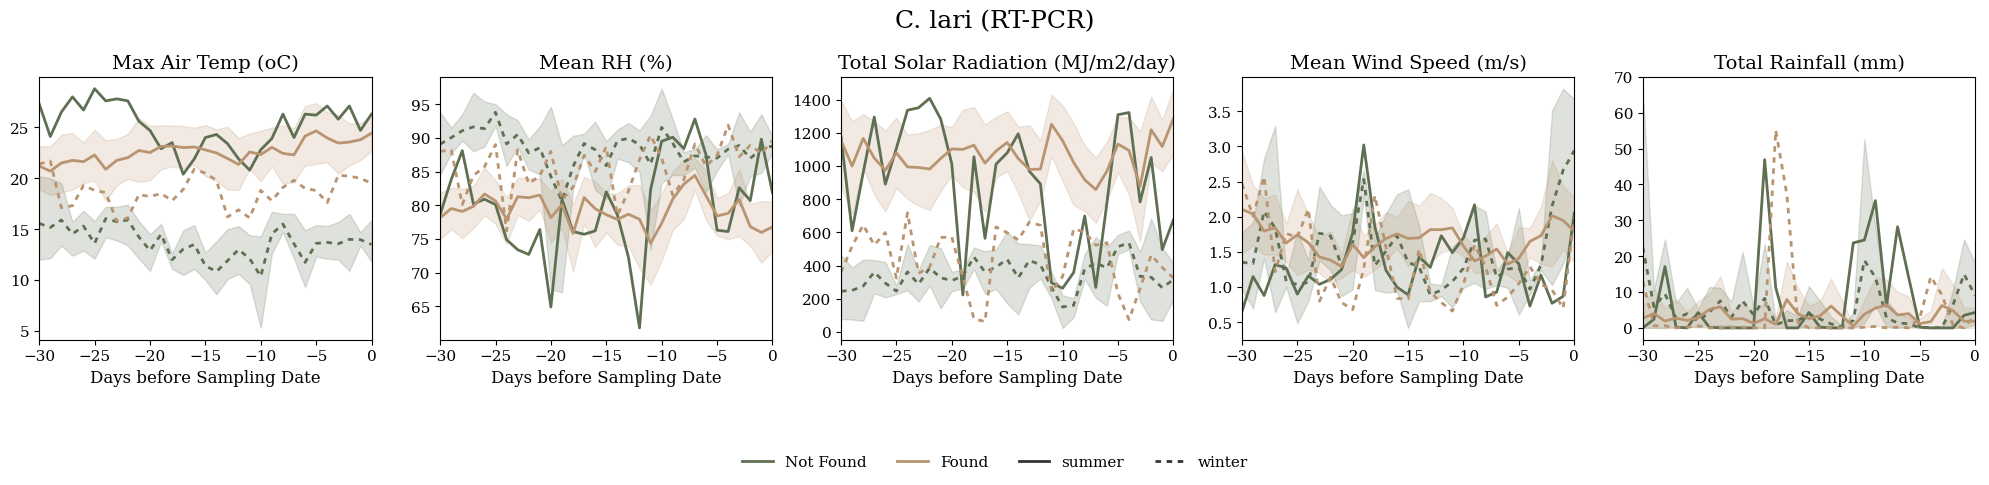

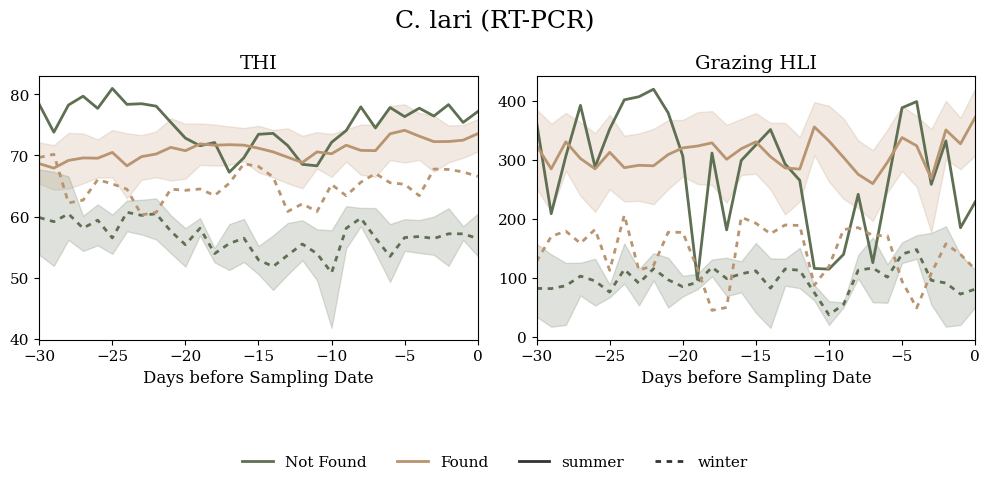

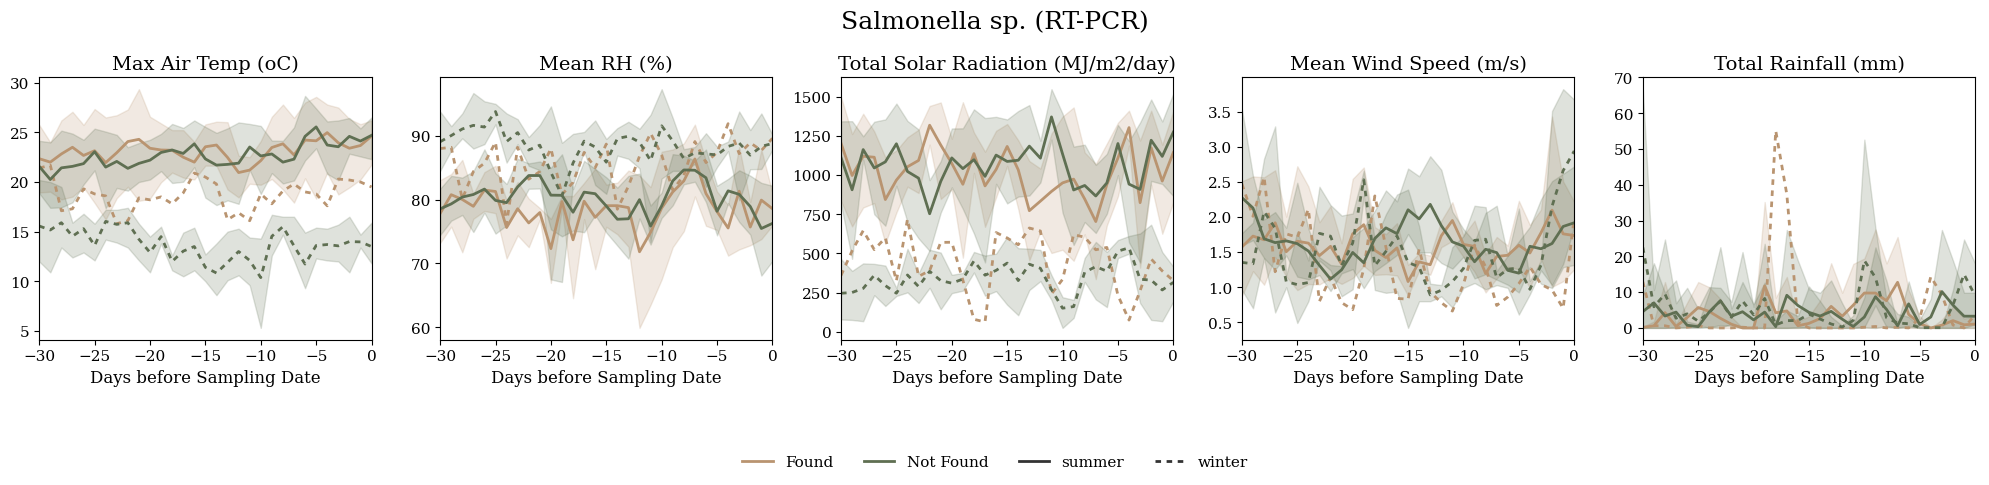

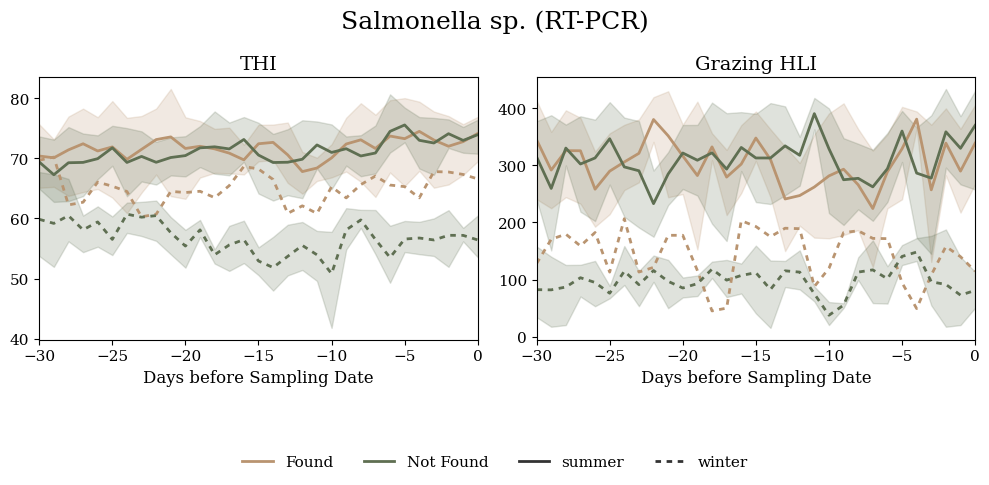

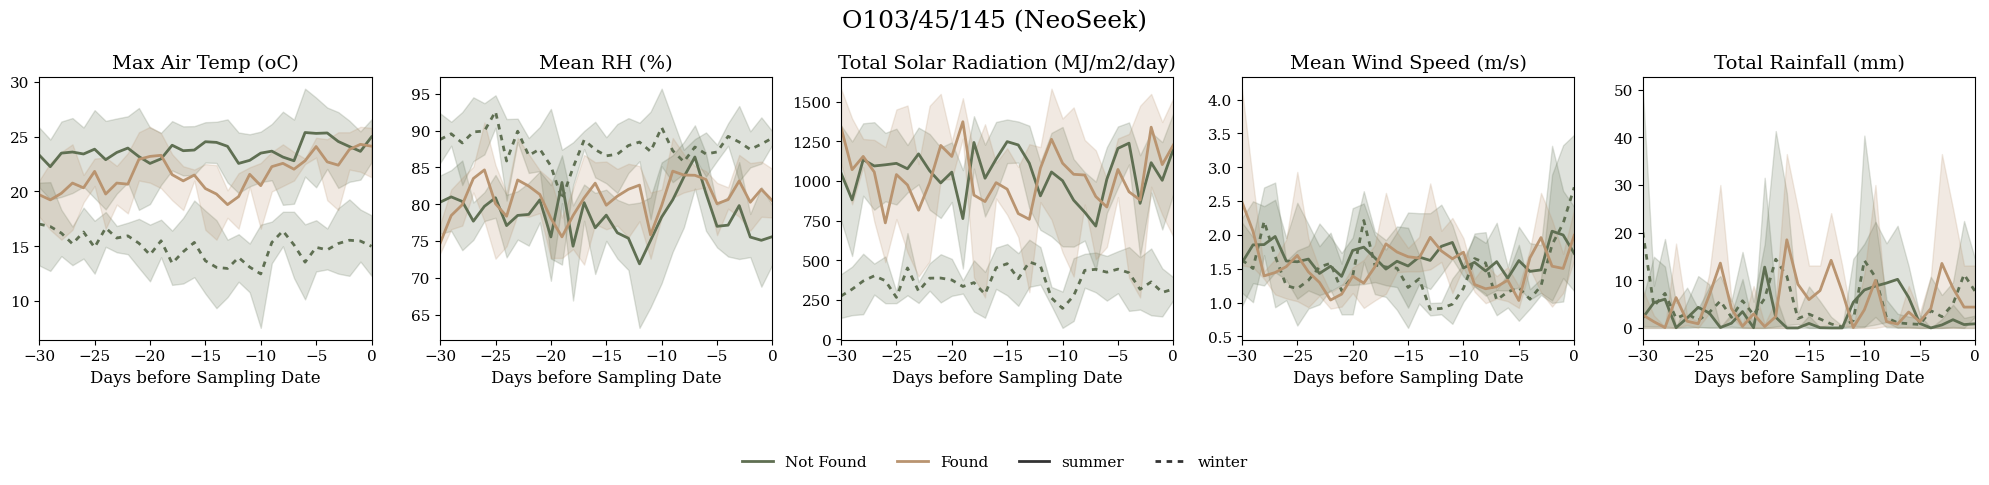

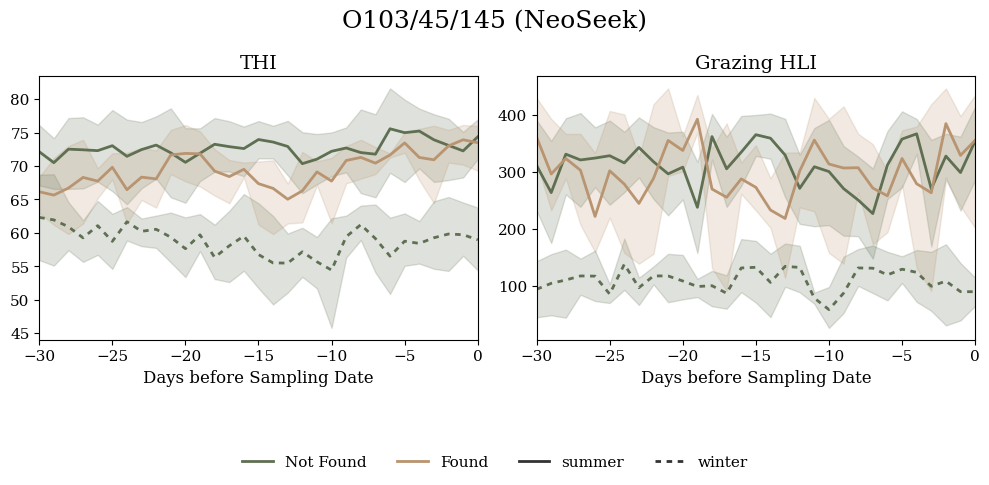

In [4]:
for col in pathogen_cols:
    records = []

    # build long dataframe: one row per (sample, day, weather-variable)
    for _, row in df.iterrows():
        sample_date = row["Date"]
        category = row[col]
        if pd.isna(category):
            category = "NA"
        
        season = row["season"]  # Get season from df

        mask = (
            (df_w["Date"] >= sample_date - pd.Timedelta(days=30)) &
            (df_w["Date"] <= sample_date)
        )
        w_sub = df_w.loc[mask].copy()
        if w_sub.empty:
            continue

        rel_days = (w_sub["Date"] - sample_date).dt.days  # -30 ... 0

        for wname in weather_cols:
            for d, val in zip(rel_days, w_sub[wname]):
                records.append({
                    "rel_day": d,
                    "weather": wname,
                    "value": val,
                    col: category,
                    "season": season,
                })

    plot_df = pd.DataFrame(records)
    if plot_df.empty:
        continue

    pos_vals = {"+", "++", "*", "1", 1, True}
    plot_df["pos_flag"] = plot_df[col].apply(lambda v: "Found" if v in pos_vals else "Not Found")
    palette = {
        "Found": COLORS[2],   # positive
        "Not Found": COLORS[0]     # negative
    }
    
    # Map season to linestyle
    dashes = {"summer": "", "winter": (2, 2), None: ""}

    # Plot 1: Original weather columns (first 5)
    orig_cols = weather_cols[:-2]
    fig, axes = plt.subplots(1, len(orig_cols), figsize=(20, 4), sharex=True)
    fig.suptitle(f"{col}", fontsize=18)

    for ax, wname in zip(axes, orig_cols):
        sub = plot_df[plot_df["weather"] == wname]

        sns.lineplot(
            data=sub,
            x="rel_day",
            y="value",
            hue="pos_flag",
            style="season",
            palette=palette,
            dashes=dashes,
            ax=ax,
            estimator="mean", # average across samples
            errorbar="ci",    # seaborn's default CI band
        )
        ax.set_title(wname)
        ax.set_xlim(-30, 0)
        ax.set_xlabel("Days before Sampling Date")
        ax.set_ylabel("")

    # Remove individual legends and create one centered below
    for ax in axes:
        ax.get_legend().remove()

    # Get handles and labels from first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    # Skip the headers (pos_flag, season) which appear as empty or header entries
    # Keep only the actual data labels
    filtered_handles = []
    filtered_labels = []
    skip_next = False
    for h, l in zip(handles, labels):
        # Skip entries that are headers (typically first entries after a new category)
        if l in ['pos_flag', 'season']:
            skip_next = True
        else:
            filtered_handles.append(h)
            filtered_labels.append(l)
    
    fig.legend(filtered_handles, filtered_labels, title=None, ncol=4, bbox_to_anchor=(0.5, -0.1), loc="upper center")

    plt.tight_layout()
    plt.show()

    # Plot 2: Heat stress indices (last 2 columns)
    heat_cols = weather_cols[-2:]
    fig, axes = plt.subplots(1, len(heat_cols), figsize=(10, 4), sharex=True)
    fig.suptitle(f"{col}", fontsize=18)

    for ax, wname in zip(axes, heat_cols):
        sub = plot_df[plot_df["weather"] == wname]

        sns.lineplot(
            data=sub,
            x="rel_day",
            y="value",
            hue="pos_flag",
            style="season",
            palette=palette,
            dashes=dashes,
            ax=ax,
            estimator="mean", # average across samples
            errorbar="ci",    # seaborn's default CI band
        )
        ax.set_title(wname)
        ax.set_xlim(-30, 0)
        ax.set_xlabel("Days before Sampling Date")
        ax.set_ylabel("")

    # Remove individual legends and create one centered below
    for ax in axes:
        ax.get_legend().remove()

    # Get handles and labels from first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    # Skip the headers (pos_flag, season)
    filtered_handles = []
    filtered_labels = []
    for h, l in zip(handles, labels):
        if l in ['pos_flag', 'season']:
            continue
        else:
            filtered_handles.append(h)
            filtered_labels.append(l)
    
    fig.legend(filtered_handles, filtered_labels, title=None, ncol=4, bbox_to_anchor=(0.5, -0.1), loc="upper center")

    plt.tight_layout()
    plt.show()


### Only Stx

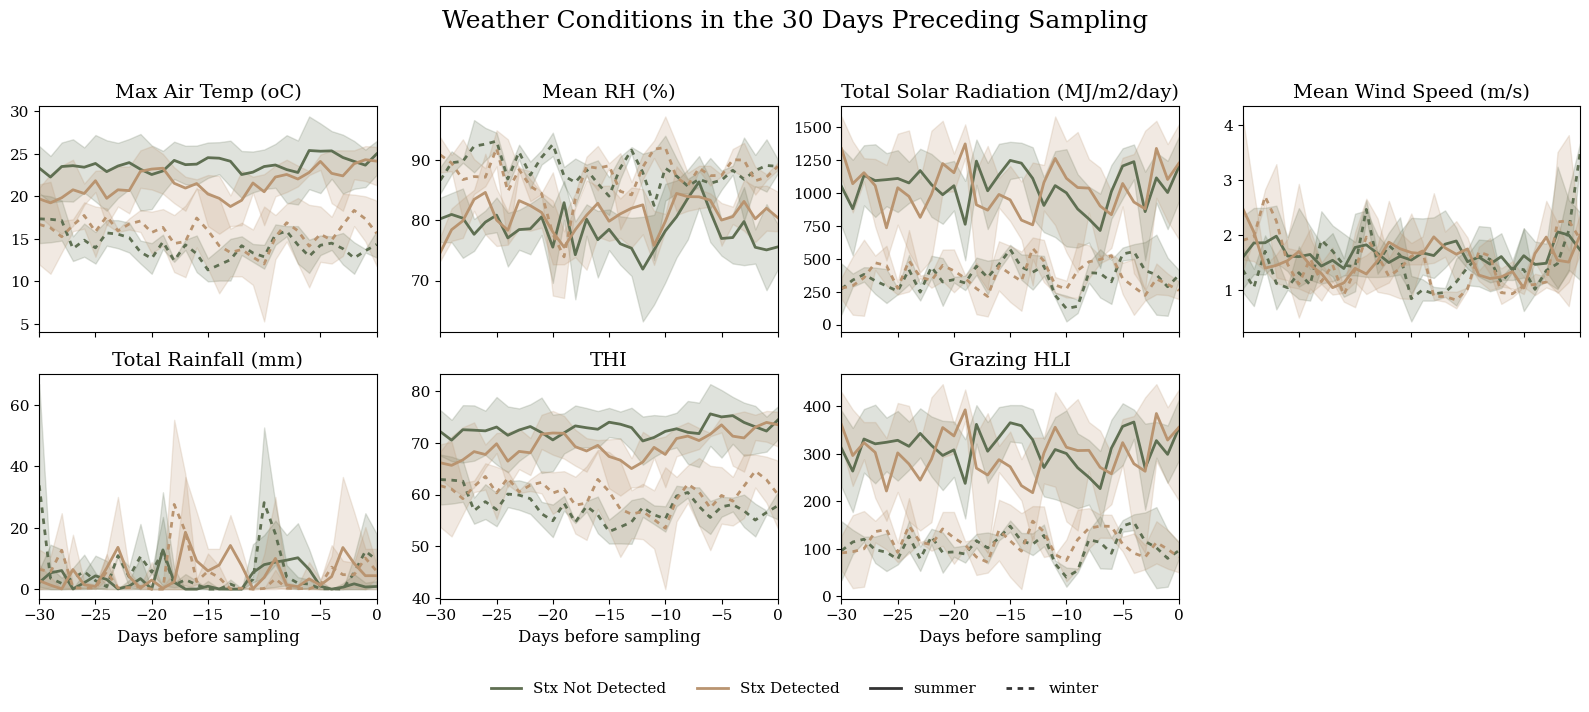

In [5]:
col = "Stx (NeoSeek)"
pos_vals = {"+", "++", "*", "1", 1, True}
palette = {"Stx Detected": COLORS[2], "Stx Not Detected": COLORS[0]}
dashes = {"summer": "", "winter": (2, 2), None: ""}

records = []

for _, row in df.iterrows():
    sample_date = row["Date"]
    w_sub = df_w.loc[df_w["Date"].between(sample_date - pd.Timedelta(days=30), sample_date), ["Date"] + list(weather_cols)]

    if w_sub.empty:
        continue

    tmp = w_sub.melt(id_vars="Date", value_vars=weather_cols, var_name="weather", value_name="value")
    tmp["rel_day"] = (tmp["Date"] - sample_date).dt.days
    tmp[col] = "NA" if pd.isna(row[col]) else row[col]
    tmp["season"] = row["season"]
    records.append(tmp[["rel_day", "weather", "value", col, "season"]])

plot_df = pd.concat(records, ignore_index=True)
plot_df["pos_flag"] = plot_df[col].apply(lambda v: "Stx Detected" if v in pos_vals else "Stx Not Detected")

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
axes = axes.ravel()

for ax, wname in zip(axes, weather_cols):
    sub = plot_df[plot_df["weather"].eq(wname)]
    sns.lineplot(data=sub, x="rel_day", y="value", hue="pos_flag", style="season", palette=palette, dashes=dashes, estimator="mean", errorbar="ci", ax=ax)
    ax.set_title(wname)
    ax.set_xlim(-30, 0)
    ax.set_xlabel("Days before sampling")
    ax.set_ylabel("")

for ax in axes[len(weather_cols):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()

keep = [(h, l) for h, l in zip(handles, labels) if l not in ["pos_flag", "season"]]
fig.legend([h for h, _ in keep], [l for _, l in keep], ncol=4, loc="lower center", bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Weather Conditions in the 30 Days Preceding Sampling", fontsize=18)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("figs/dairy_stx_weather_conditions_preceding_sampling.svg", bbox_inches="tight")
plt.savefig("figs/dairy_stx_weather_conditions_preceding_sampling.png", dpi=300, bbox_inches="tight")
plt.show()

# Functional T-Tests

In [6]:
def build_fd_for_weather(df, df_w, pathogen_col, weather_col, window_days=30, season=None):
    grid = np.arange(-window_days, 1)  # -30 … 0

    curves_pos = []
    curves_neg = []
    pos_vals = {1, "1", "+", "++", "+-", "-+", "*"}

    for _, row in df.iterrows():
        sample_date = row["Date"]
        y = row[pathogen_col]
        
        # Filter by season if specified
        if season is not None and row.get("season") != season:
            continue

        if pd.isna(y):
            continue

        # Extract weather window
        mask = (
            (df_w["Date"] >= sample_date - pd.Timedelta(days=window_days)) &
            (df_w["Date"] <= sample_date)
        )
        sub = df_w.loc[mask, ["Date", weather_col]].copy()
        if sub.empty:
            continue

        sub["rel_day"] = (sub["Date"] - sample_date).dt.days
        s = sub.set_index("rel_day")[weather_col].reindex(grid).interpolate(
            limit_direction="both"
        )

        if s.isna().any():
            continue

        if y in pos_vals:
            curves_pos.append(s.values)
        else:
            curves_neg.append(s.values)

    if len(curves_pos) < 2 or len(curves_neg) < 2:
        return None, None, grid

    return (
        FDataGrid(np.array(curves_pos), grid_points=grid),
        FDataGrid(np.array(curves_neg), grid_points=grid),
        grid,
    )

In [ ]:
# results = []

# for pathogen_col in pathogen_cols:
#     for wcol in weather_cols:
#         for season in ["summer", "winter", None]:
#             fd_pos, fd_neg, grid = build_fd_for_weather(df, df_w, pathogen_col, wcol, season=season)

#             if fd_pos is None:
#                 continue

#             stat, pval = hotelling_test_ind(fd_pos, fd_neg)

#             season_label = season if season is not None else "all"
#             results.append({
#                 "pathogen": pathogen_col,
#                 "weather": wcol,
#                 "season": season_label,
#                 "statistic": float(stat),
#                 "pvalue": float(pval),
#             })

# res_df = pd.DataFrame(results).sort_values("pvalue")
# res_df.to_csv("results/dairy_weather_hotelling_results_new.csv", index=False)

In [ ]:
res_df = pd.read_csv("results/dairy_weather_hotelling_results_new.csv")

In [8]:
res_df.head(20)

,pathogen,weather,season,statistic,pvalue
21,Stx (NeoSeek),Total Rainfall (mm),all,93.606529,0.034846
15,Stx (NeoSeek),Total Solar Radiation (MJ/m2/day),all,28.886723,0.057817
27,Stx (NeoSeek),Grazing HLI,all,25.913593,0.062060
33,C. lari (RT-PCR),THI,all,50.329045,0.097118
28,C. lari (RT-PCR),Max Air Temp (oC),all,62.315508,0.098002
12,Stx (NeoSeek),Mean RH (%),all,28.470359,0.099190
32,C. lari (RT-PCR),Total Rainfall (mm),all,76.295505,0.105853
13,Stx (NeoSeek),Total Solar Radiation (MJ/m2/day),summer,3.387895,0.142857
53,O103/45/145 (NeoSeek),Total Solar Radiation (MJ/m2/day),summer,3.387895,0.142857
57,O103/45/145 (NeoSeek),Total Rainfall (mm),summer,9.681311,0.160714


In [10]:
# path_order = ["Stx (NeoSeek)", "O103/45/145 (NeoSeek)"]
# season_order = ["all", "summer", "winter"]

# tab = res_df[res_df["pathogen"].isin(path_order) & res_df["season"].isin(season_order)].copy()
# tab["pathogen"] = pd.Categorical(tab["pathogen"], path_order, ordered=True)
# tab["season"] = pd.Categorical(tab["season"], season_order, ordered=True)
# tab = tab.sort_values(["pathogen", "season", "pvalue"])

# def esc(s):
#     return str(s).replace("%", r"\%").replace("_", r"\_")

# lines = [
#     r"\begin{table}",
#     r"\centering",
#     r"\caption{...}",
#     r"\label{tab:dairy_hotelling_results}",
#     r"\begin{tabular}{lllrrr}",
#     r"\toprule",
#     r"Pathogen & Season & No. & Weather variable & Statistic & $p$-value \\",
#     r"\midrule",
# ]

# for i, pathogen in enumerate(path_order):
#     ptab = tab[tab["pathogen"].eq(pathogen)]
#     if ptab.empty:
#         continue

#     if i > 0:
#         lines.append(r"\midrule")

#     first_pathogen_row = True

#     for season in season_order:
#         stab = ptab[ptab["season"].eq(season)].reset_index(drop=True)
#         if stab.empty:
#             continue

#         if not first_pathogen_row:
#             lines.append(r"\cmidrule(lr){2-6}")

#         first_season_row = True

#         for j, row in stab.iterrows():
#             pathogen_text = esc(pathogen) if first_pathogen_row else ""
#             season_text = season if first_season_row else ""
#             lines.append(
#                 f"{pathogen_text} & {season_text} & {j+1} & {esc(row['weather'])} & "
#                 f"{row['statistic']:.2f} & {row['pvalue']:.3f} \\\\"
#             )
#             first_pathogen_row = False
#             first_season_row = False

# lines += [
#     r"\bottomrule",
#     r"\end{tabular}",
#     r"\end{table}",
# ]

# latex = "\n".join(lines)
# print(latex)

# Functional Logistic Regression

In [11]:
def fit_functional_logistic(df, df_w, pathogen_col, weather_col, window_days=30, n_basis=7, season=None):
    grid = np.arange(-window_days, 1)

    X_curves = []
    y_vec = []

    for _, row in df.iterrows():
        sample_date = row["Date"]
        y = row[pathogen_col]

        # Filter by season if specified
        if season is not None and row.get("season") != season:
            continue

        if pd.isna(y):
            continue
        y = 1 if y in {1, "1", "+", "++", "+-", "-+", "*"} else 0

        mask = (
            (df_w["Date"] >= sample_date - pd.Timedelta(days=window_days)) &
            (df_w["Date"] <= sample_date)
        )
        sub = df_w.loc[mask, ["Date", weather_col]].copy()
        if sub.empty:
            continue

        sub["rel_day"] = (sub["Date"] - sample_date).dt.days
        s = sub.set_index("rel_day")[weather_col].reindex(grid).interpolate(limit_direction="both")

        if s.isna().any():
            continue

        X_curves.append(s.values)
        y_vec.append(y)

    if len(X_curves) < 5:
        raise ValueError("Not enough samples to fit functional logistic regression.")

    X_curves = np.array(X_curves)
    y_vec = np.array(y_vec)

    # ---- Functional representation as FDataGrid ----
    fd = FDataGrid(data_matrix=X_curves, grid_points=grid)

    # ---- Convert to B-spline basis ----
    basis = BSplineBasis(n_basis=n_basis, domain_range=(grid[0], grid[-1]))
    fd_basis = fd.to_basis(basis)

    # Basis coefficients become predictors
    X_basis = fd_basis.coefficients  # shape: (n_samples, n_basis)

    # ---- Fit logistic regression ----
    clf = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000)
    clf.fit(X_basis, y_vec)

    # ---- Recover coefficient function β(t) ----
    # Evaluate basis functions on the grid: shape ≈ (len(grid), n_basis, 1)
    B = basis.evaluate(grid)[:, :, 0].T   # take the first (and only) dimension
    # β(t) = sum_j w_j * φ_j(t)

    coef_func = B @ clf.coef_.ravel()   # shape: (len(grid),)

    return clf, coef_func, grid, basis

In [12]:
def bootstrap_beta(
    df, df_w, pathogen_col, weather_col,
    window_days=30, n_basis=7, n_boot=2000, season=None
):
    # --- 1. build design once (same as inside fit_functional_logistic) ---
    grid = np.arange(-window_days, 1)

    X_curves = []
    y_vec = []
    for _, row in df.iterrows():
        sample_date = row["Date"]
        y = row[pathogen_col]
        
        # Filter by season if specified
        if season is not None and row.get("season") != season:
            continue
        
        if pd.isna(y):
            continue
        y = 1 if y in {1, "1", "+", "++", "+-", "-+", "*"} else 0

        mask = (
            (df_w["Date"] >= sample_date - pd.Timedelta(days=window_days)) &
            (df_w["Date"] <= sample_date)
        )
        sub = df_w.loc[mask, ["Date", weather_col]]
        if sub.empty:
            continue

        rel = (sub["Date"] - sample_date).dt.days
        s = sub.assign(rel_day=rel).set_index("rel_day")[weather_col] \
                .reindex(grid).interpolate(limit_direction="both")

        if s.isna().any():
            continue

        X_curves.append(s.values)
        y_vec.append(y)

    X_curves = np.array(X_curves)
    y_vec = np.array(y_vec)

    # need both classes at least once
    if len(np.unique(y_vec)) < 2:
        raise ValueError("Pathogen has only one class across all samples.")

    fd = FDataGrid(data_matrix=X_curves, grid_points=grid)
    basis = BSplineBasis(n_basis=n_basis, domain_range=(grid[0], grid[-1]))
    fd_basis = fd.to_basis(basis)
    X_basis = fd_basis.coefficients
    B_eval = basis(grid)[:, :, 0].T  # (len(grid), n_basis)

    n = len(y_vec)

    # --- 2. fit model on full data to get beta_hat ---
    clf_full = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000)
    clf_full.fit(X_basis, y_vec)
    beta_hat = B_eval @ clf_full.coef_.ravel()

    # --- 3. bootstrap ---
    beta_samples = []

    for b in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        y_b = y_vec[idx]

        # skip resamples with only one class
        if len(np.unique(y_b)) < 2:
            continue

        clf_b = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000)
        clf_b.fit(X_basis[idx], y_b)
        beta_b = B_eval @ clf_b.coef_.ravel()
        beta_samples.append(beta_b)

    beta_samples = np.array(beta_samples)
    if beta_samples.shape[0] < 100:
        print(f"Warning: only {beta_samples.shape[0]} valid bootstrap samples; CIs will be noisy.")


    lower = np.percentile(beta_samples, 5, axis=0)
    upper = np.percentile(beta_samples, 95, axis=0)    
    return beta_hat, lower, upper, grid


In [13]:
def plot_functional_effect(df, df_w, pathogen_col, weather_col, alpha_level=0.90, season=None, save_fig=False):
    try:
        beta, lower, upper, grid = bootstrap_beta(df, df_w, pathogen_col, weather_col, season=season)
    except ValueError as e:
        # e.g. only one class overall
        print(f"Skipping {pathogen_col} / {weather_col} (season={season}): {e}")
        return

    # significant region: CI excludes 0
    sig_mask = (lower > 0) | (upper < 0)
    if not sig_mask.any():
        # nothing interesting here
        return

    fig, ax = plt.subplots(figsize=(6, 3.5))

    ax.axhline(0, color="black", linewidth=1)

    # main effect curve
    ax.plot(grid, beta, color=COLORS[1], label="Effect β(t)")

    # CI band
    ax.fill_between(
        grid, lower, upper,
        color=COLORS[1],
        alpha=0.2,
        label=f"{int(alpha_level*100)}% CI",
    )

    # significant part of CI
    ax.fill_between(
        grid, lower, upper,
        where=sig_mask,
        color=COLORS[2],
        alpha=0.4,
        interpolate=True,
        label=f"Significant ({int(alpha_level*100)}%)",
    )

    ax.set_xlabel("Days before sampling")
    ax.set_ylabel("Effect on log-odds\nof Pathogen found")
    season_label = f" ({season})" if season is not None else ""
    ax.set_title(f"Effect of {weather_col} on {pathogen_col}{season_label}")
    ax.legend(frameon=False)
    plt.tight_layout()
    if save_fig:
        plt.savefig(f"figs/dairy_FLR{pathogen_col}_{weather_col}_{season}.png", dpi=300, bbox_inches="tight")
    plt.show()


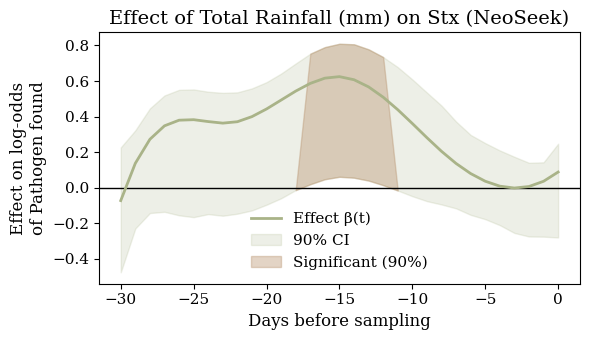

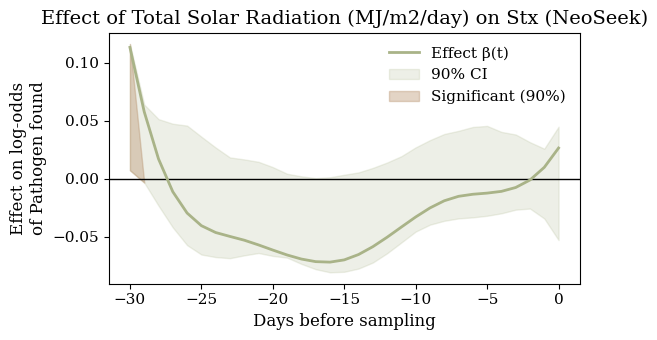

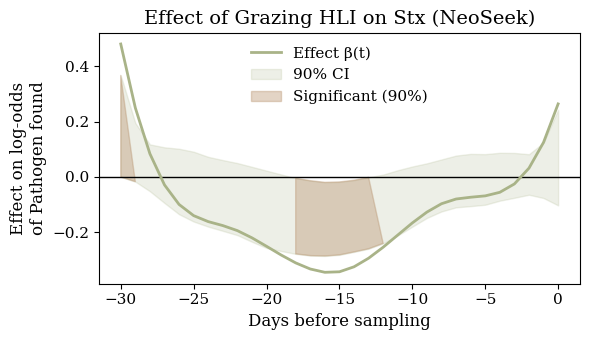

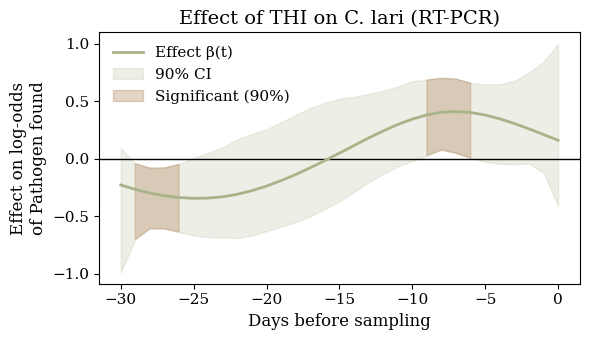

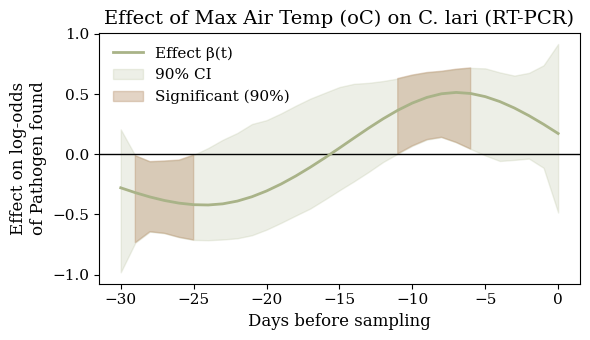

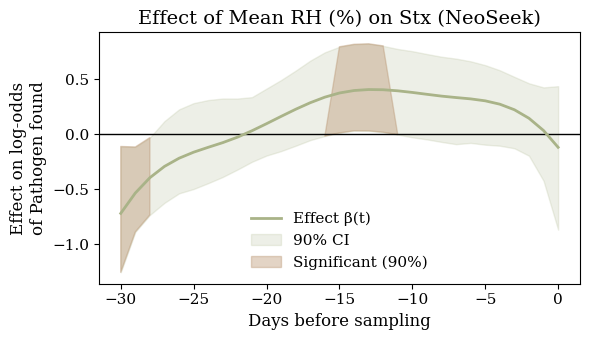

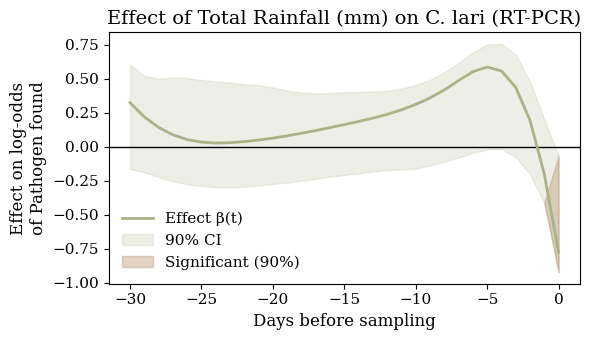

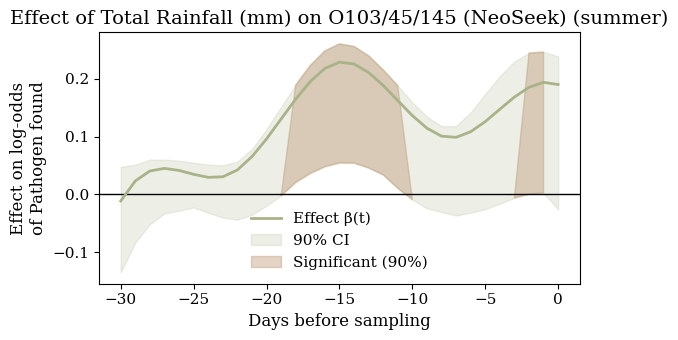

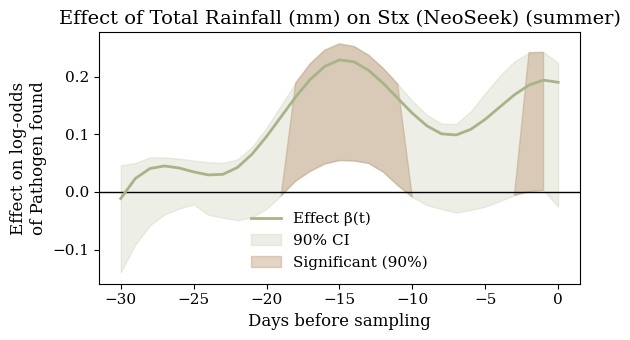

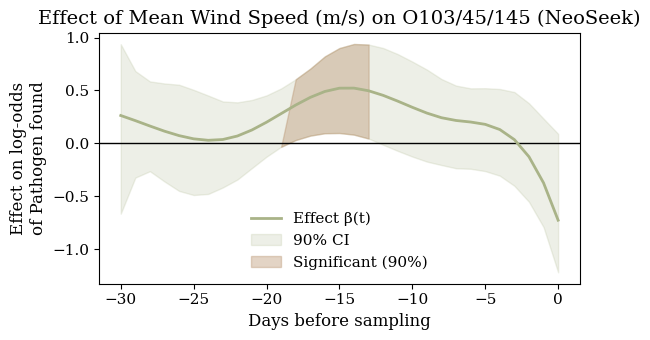

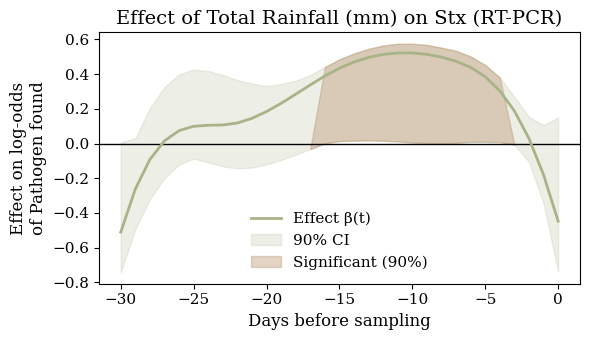

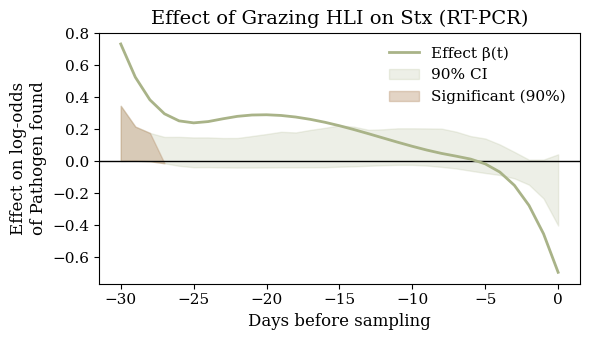

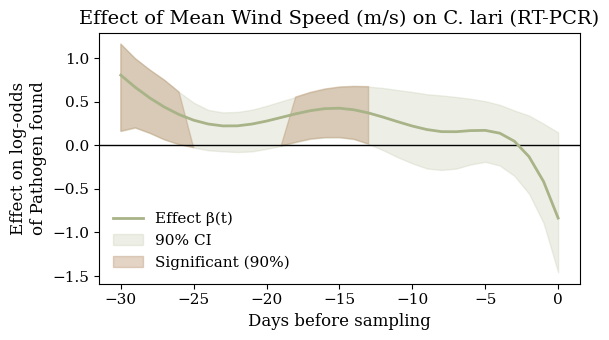

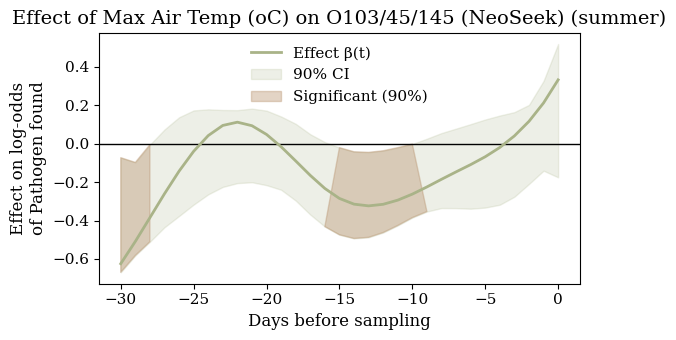

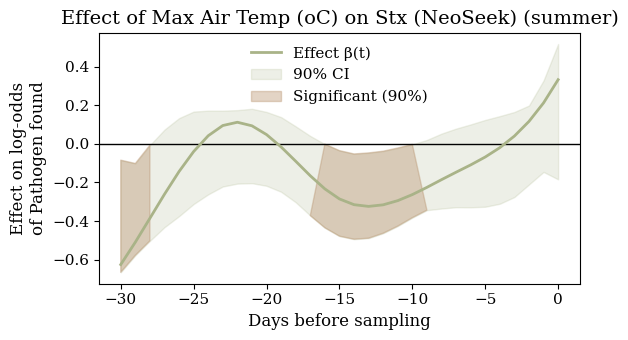

In [14]:
# run only for top 20 significant combinations from Hotelling tests, stratified by season
for _, row in res_df.head(20).iterrows():
    pathogen_col = row["pathogen"]
    weather_col = row["weather"]

    season = None if row["season"] == "all" else row["season"]    
    plot_functional_effect(df, df_w, pathogen_col, weather_col, season=season)

### Only Stx

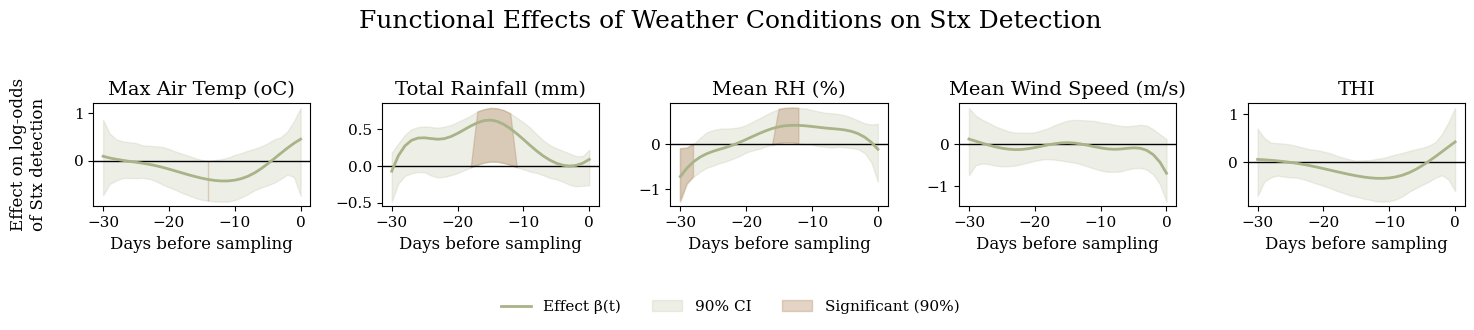

In [15]:
# Stx all year
pathogen_col = "Stx (NeoSeek)"
weather_cols_plot = ['Max Air Temp (oC)', 'Total Rainfall (mm)', 'Mean RH (%)',
       'Mean Wind Speed (m/s)', 'THI']
alpha_level = 0.90
season = None

fig, axes = plt.subplots(1, len(weather_cols_plot), figsize=(3 * len(weather_cols_plot), 3), sharex=True)
axes = [axes] if len(weather_cols_plot) == 1 else axes

for ax, weather_col in zip(axes, weather_cols_plot):
    try:
        beta, lower, upper, grid = bootstrap_beta(df, df_w, pathogen_col, weather_col, season=season)
    except ValueError as e:
        ax.set_axis_off()
        ax.set_title(weather_col)
        print(f"Skipping {weather_col}: {e}")
        continue

    sig_mask = (lower > 0) | (upper < 0)

    ax.axhline(0, color="black", linewidth=1)
    ax.plot(grid, beta, color=COLORS[1], label="Effect β(t)")
    ax.fill_between(grid, lower, upper, color=COLORS[1], alpha=0.2, label=f"{int(alpha_level*100)}% CI")
    ax.fill_between(grid, lower, upper, where=sig_mask, color=COLORS[2], alpha=0.4, interpolate=True, label=f"Significant ({int(alpha_level*100)}%)")

    ax.set_title(weather_col)
    ax.set_xlabel("Days before sampling")
    ax.set_ylabel("")

fig.suptitle("Functional Effects of Weather Conditions on Stx Detection", fontsize=18)
fig.supylabel("Effect on log-odds\nof Stx detection")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.savefig("figs/dairy_FLR_stx_allyear.svg", bbox_inches="tight")
plt.savefig("figs/dairy_FLR_stx_allyear.png", dpi=300, bbox_inches="tight")
plt.show()

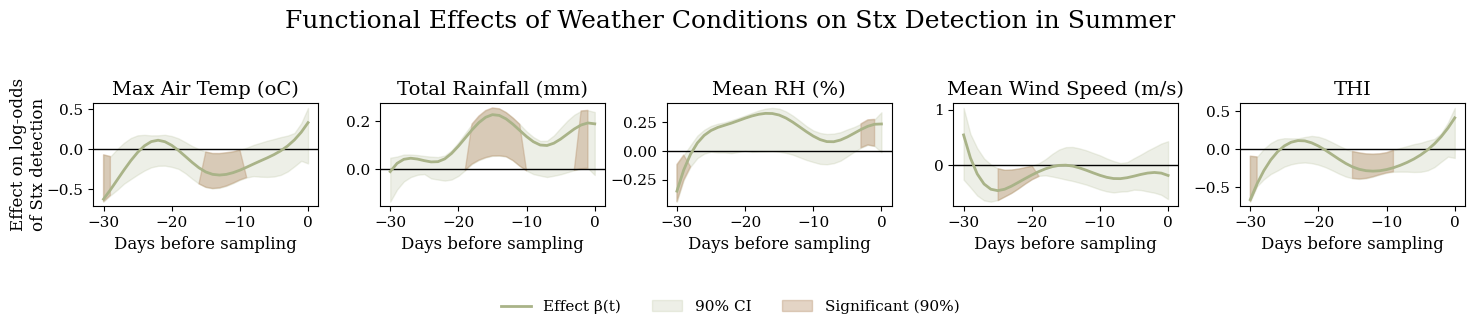

In [16]:
# Stx summer
pathogen_col = "Stx (NeoSeek)"
weather_cols_plot = ['Max Air Temp (oC)', 'Total Rainfall (mm)', 'Mean RH (%)',
       'Mean Wind Speed (m/s)', 'THI']
alpha_level = 0.90
season = "summer"

fig, axes = plt.subplots(1, len(weather_cols_plot), figsize=(3 * len(weather_cols_plot), 3), sharex=True)
axes = [axes] if len(weather_cols_plot) == 1 else axes

for ax, weather_col in zip(axes, weather_cols_plot):
    try:
        beta, lower, upper, grid = bootstrap_beta(df, df_w, pathogen_col, weather_col, season=season)
    except ValueError as e:
        ax.set_axis_off()
        ax.set_title(weather_col)
        print(f"Skipping {weather_col}: {e}")
        continue

    sig_mask = (lower > 0) | (upper < 0)

    ax.axhline(0, color="black", linewidth=1)
    ax.plot(grid, beta, color=COLORS[1], label="Effect β(t)")
    ax.fill_between(grid, lower, upper, color=COLORS[1], alpha=0.2, label=f"{int(alpha_level*100)}% CI")
    ax.fill_between(grid, lower, upper, where=sig_mask, color=COLORS[2], alpha=0.4, interpolate=True, label=f"Significant ({int(alpha_level*100)}%)")

    ax.set_title(weather_col)
    ax.set_xlabel("Days before sampling")
    ax.set_ylabel("")

fig.suptitle("Functional Effects of Weather Conditions on Stx Detection in Summer", fontsize=18)
fig.supylabel("Effect on log-odds\nof Stx detection")


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.savefig("figs/dairy_FLR_stx_summer.svg", bbox_inches="tight")
plt.savefig("figs/dairy_FLR_stx_summer.png", dpi=300, bbox_inches="tight")
plt.show()

### Only STEC

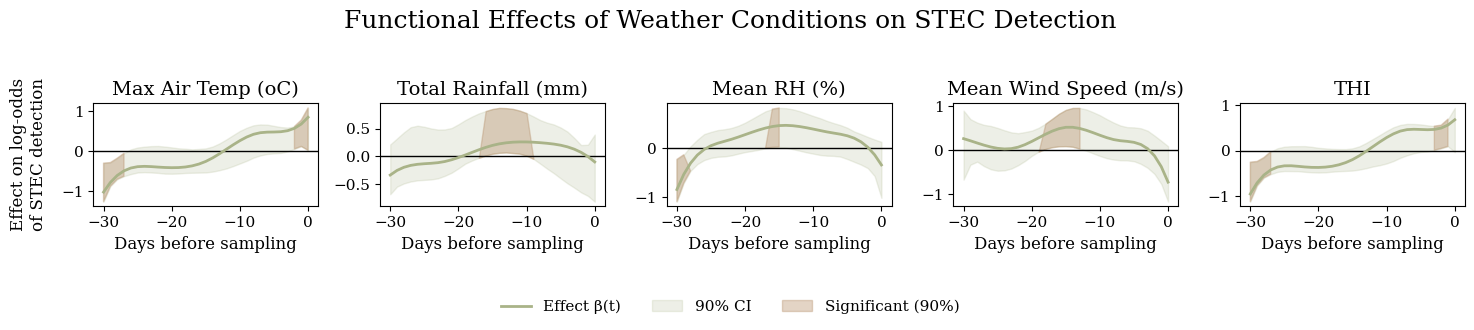

In [17]:
# STEC all year
pathogen_col = "O103/45/145 (NeoSeek)"
weather_cols_plot = ['Max Air Temp (oC)', 'Total Rainfall (mm)', 'Mean RH (%)',
       'Mean Wind Speed (m/s)', 'THI']
alpha_level = 0.90
season = None

fig, axes = plt.subplots(1, len(weather_cols_plot), figsize=(3 * len(weather_cols_plot), 3), sharex=True)
axes = [axes] if len(weather_cols_plot) == 1 else axes

for ax, weather_col in zip(axes, weather_cols_plot):
    try:
        beta, lower, upper, grid = bootstrap_beta(df, df_w, pathogen_col, weather_col, season=season)
    except ValueError as e:
        ax.set_axis_off()
        ax.set_title(weather_col)
        print(f"Skipping {weather_col}: {e}")
        continue

    sig_mask = (lower > 0) | (upper < 0)

    ax.axhline(0, color="black", linewidth=1)
    ax.plot(grid, beta, color=COLORS[1], label="Effect β(t)")
    ax.fill_between(grid, lower, upper, color=COLORS[1], alpha=0.2, label=f"{int(alpha_level*100)}% CI")
    ax.fill_between(grid, lower, upper, where=sig_mask, color=COLORS[2], alpha=0.4, interpolate=True, label=f"Significant ({int(alpha_level*100)}%)")

    ax.set_title(weather_col)
    ax.set_xlabel("Days before sampling")
    ax.set_ylabel("")

fig.suptitle("Functional Effects of Weather Conditions on STEC Detection", fontsize=18)
fig.supylabel("Effect on log-odds\nof STEC detection")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.savefig("figs/dairy_FLR_STEC_allyear.svg", bbox_inches="tight")
plt.savefig("figs/dairy_FLR_STEC_allyear.png", dpi=300, bbox_inches="tight")
plt.show()

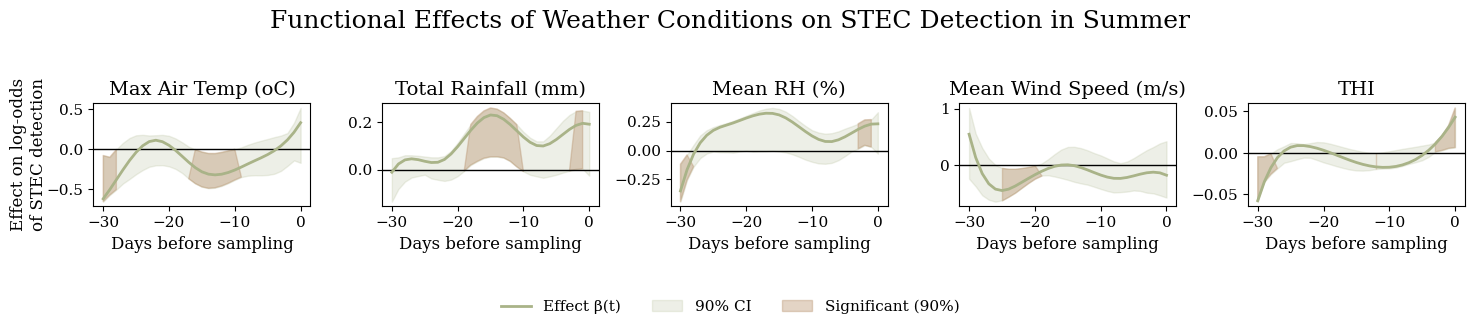

In [61]:
# STEC summer
pathogen_col = "O103/45/145 (NeoSeek)"
weather_cols_plot = ['Max Air Temp (oC)', 'Total Rainfall (mm)', 'Mean RH (%)',
       'Mean Wind Speed (m/s)', 'THI']
alpha_level = 0.90
season = "summer"

fig, axes = plt.subplots(1, len(weather_cols_plot), figsize=(3 * len(weather_cols_plot), 3), sharex=True)
axes = [axes] if len(weather_cols_plot) == 1 else axes

for ax, weather_col in zip(axes, weather_cols_plot):
    try:
        beta, lower, upper, grid = bootstrap_beta(df, df_w, pathogen_col, weather_col, season=season)
    except ValueError as e:
        ax.set_axis_off()
        ax.set_title(weather_col)
        print(f"Skipping {weather_col}: {e}")
        continue

    sig_mask = (lower > 0) | (upper < 0)

    ax.axhline(0, color="black", linewidth=1)
    ax.plot(grid, beta, color=COLORS[1], label="Effect β(t)")
    ax.fill_between(grid, lower, upper, color=COLORS[1], alpha=0.2, label=f"{int(alpha_level*100)}% CI")
    ax.fill_between(grid, lower, upper, where=sig_mask, color=COLORS[2], alpha=0.4, interpolate=True, label=f"Significant ({int(alpha_level*100)}%)")

    ax.set_title(weather_col)
    ax.set_xlabel("Days before sampling")
    ax.set_ylabel("")

fig.suptitle("Functional Effects of Weather Conditions on STEC Detection in Summer", fontsize=18)
fig.supylabel("Effect on log-odds\nof STEC detection")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.08))

plt.tight_layout(rect=[0, 0.12, 1, 0.92])
plt.savefig("figs/dairy_FLR_STEC_summer.svg", bbox_inches="tight")
plt.savefig("figs/dairy_FLR_STEC_summer.png", dpi=300, bbox_inches="tight")
plt.show()

# Decision Trees

In [18]:
# windows defined as tuples (start_day, end_day), inclusive
WINDOWS = [
    (-4, -1),
    (-10, -5),
    (-20, -11),
    (-30, -21),
]

In [19]:
def extract_window_features(df_w, sample_date, weather_col):
    features = {}
    for (start, end) in WINDOWS:
        mask = (
            (df_w["Date"] >= sample_date + pd.Timedelta(days=start)) &
            (df_w["Date"] <= sample_date + pd.Timedelta(days=end))
        )
        w = df_w.loc[mask, weather_col]

        key = f"{weather_col}_{start}_{end}"
        features[key + "_mean"] = w.mean() if not w.empty else np.nan
        features[key + "_max"]  = w.max()  if not w.empty else np.nan
    return features


In [20]:
def build_dataset_for_pathogen(df, df_w, pathogen_col, weather_cols):
    X_rows = []
    y_rows = []

    for _, row in df.iterrows():
        sample_date = row["Date"]
        y = row[pathogen_col]

        if pd.isna(y):
            continue

        # convert pathogen column to binary
        y = 1 if y in {1, "1", "+", "++", "+-", "-+", "*"} else 0

        feats = {}
        for wcol in weather_cols:
            feats.update(extract_window_features(df_w, sample_date, wcol))

        if all(pd.isna(v) for v in feats.values()):
            continue

        X_rows.append(feats)
        y_rows.append(y)

    X = pd.DataFrame(X_rows)
    y = np.array(y_rows)

    # Remove columns with all-NaN
    X = X.dropna(axis=1, how="all")

    # Fill internal NaNs (if any) with column means
    X = X.fillna(X.mean())

    return X, y


In [21]:
def train_decision_tree(X, y):
    clf = DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=2,
        random_state=0
    )
    clf.fit(X, y)
    return clf

In [22]:
def plot_pruning_curve(X, y, pathogen_col, cv=5, scoring="accuracy"):
    clf = DecisionTreeClassifier(random_state=0)
    path = clf.cost_complexity_pruning_path(X, y)
    ccp_alphas = path.ccp_alphas[:-1]  # skip tree pruned to root only

    mean_scores = []
    std_scores = []

    for alpha in ccp_alphas:
        clf_pruned = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha)
        scores = cross_val_score(clf_pruned, X, y, cv=cv, scoring=scoring)
        mean_scores.append(scores.mean())
        std_scores.append(scores.std())

    best_idx = np.argmax(mean_scores)
    best_alpha = ccp_alphas[best_idx]

    plt.figure(figsize=(6, 3.5))
    plt.errorbar(ccp_alphas, mean_scores, yerr=std_scores, marker="o", color=COLORS[1], capsize=3)
    plt.axvline(best_alpha, color=COLORS[2], linestyle="--", label=f"best alpha = {best_alpha:.4g}")
    plt.xlabel("ccp_alpha")
    plt.ylabel(f"CV {scoring}")
    plt.title(f"Pruning curve for {pathogen_col}")
    plt.legend(frameon=False)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Best ccp_alpha:", best_alpha)
    print("Best CV score:", mean_scores[best_idx])

    return best_alpha

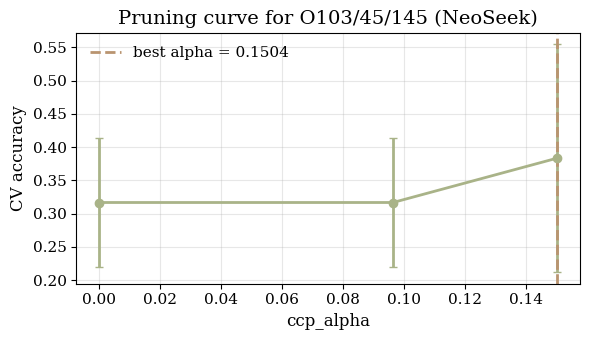

Best ccp_alpha: 0.15037593984962405
Best CV score: 0.3833333333333333


np.float64(0.15037593984962405)

In [29]:
col = pathogen_cols[5]
X, y = build_dataset_for_pathogen(df, df_w, col, weather_cols)
plot_pruning_curve(X, y, col)

In [30]:
ccp_alphas = [0, 0, 0, 0.16240601503759397, 0, 0.15037593984962405]

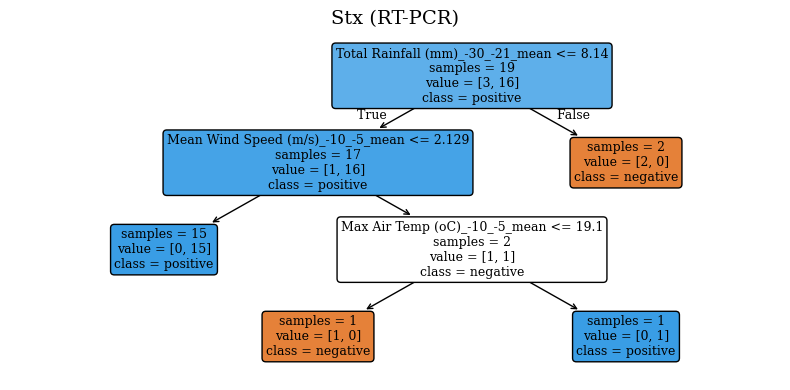

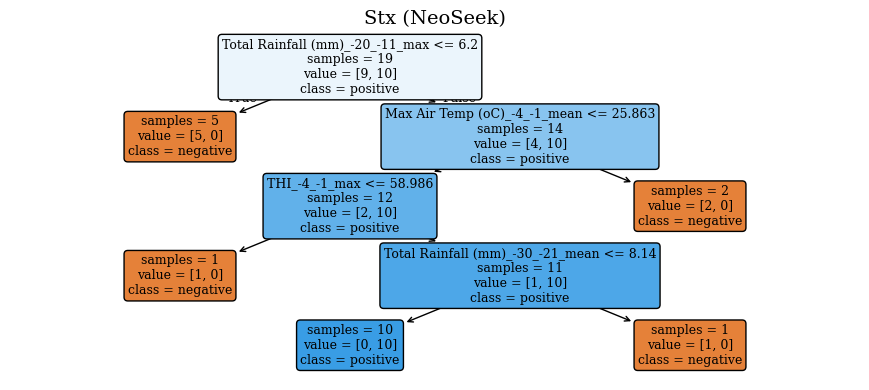

Skipping Top 7 STEC (RT-PCR): only one class.


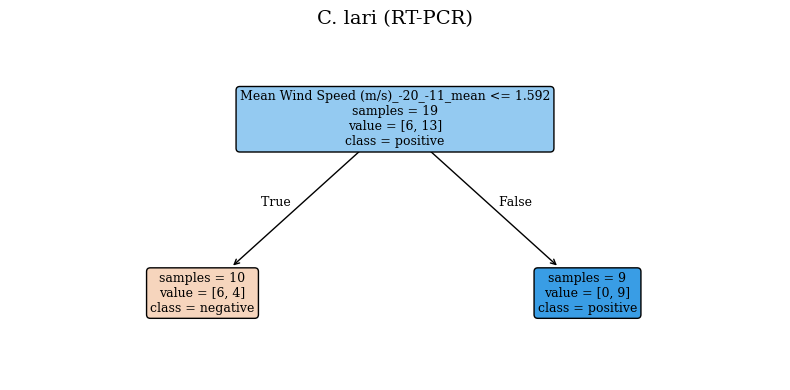

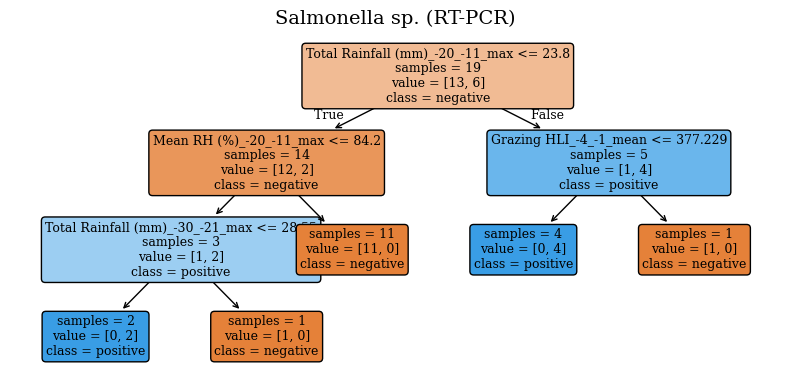

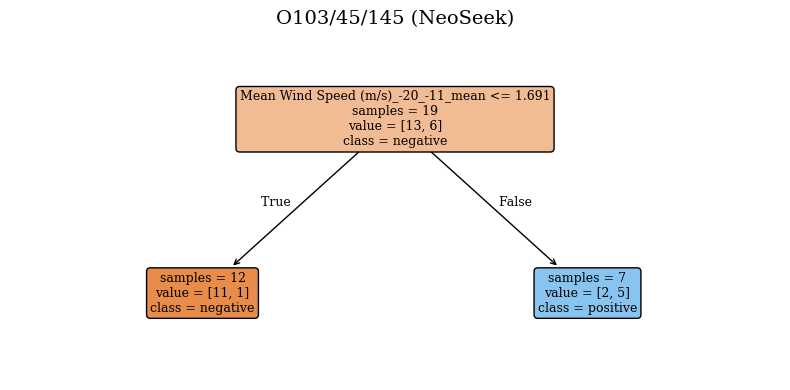

In [31]:
def auto_figsize(tree):
    """Scale figure width/height based on tree size."""
    n_nodes = tree.tree_.node_count
    depth = tree.get_depth()
    # heuristic: wider trees need wider figures
    width = max(8, min(20, depth * 2.2))
    height = max(4, min(20, n_nodes * 0.25))
    return (width, height)


for pathogen_col, alpha in zip(pathogen_cols, ccp_alphas):

    # ---- Build dataset ----
    X, y = build_dataset_for_pathogen(df, df_w, pathogen_col, weather_cols)
    if len(np.unique(y)) < 2:
        print(f"Skipping {pathogen_col}: only one class.")
        continue

    # ---- Fit pruned tree ----
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha)
    clf.fit(X, y)

    # ---- Custom class colors ----
    # scikit-learn uses one color per class in class_order: ["neg","pos"]
    class_colors = {0: COLORS[1], 1: COLORS[2]}  # neg → COLORS[1], pos → COLORS[2]
    node_classes = clf.tree_.value.argmax(axis=2).flatten()  # class per node

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=auto_figsize(clf))
    plot_tree(
        clf,
        feature_names=X.columns,
        class_names=["negative", "positive"],
        filled=True,
        rounded=True,
        impurity=False,
        fontsize=9,
        ax=ax,
    )

    ax.set_title(pathogen_col)
    plt.tight_layout()
    plt.show()